In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_kaggle = pd.read_csv('./stats/kaggle_7_8/in_top10_features.csv', index_col='dataset_name')
df_kaggle

,AQD,CNT,DFW,DHL,FPA,GAG,GGS,IWG,LYP,PYY,...,ELL,ILV,LVW,MVK,STE,VKE,YWA,YYQ,random_seed,dataset
dataset_name,,,,,,,,,,,,,,,,,,,,,
dataset_7_46,0.001864,0.002279,0.003941,0.002282,0.001736,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46,dataset_7
dataset_8_46,NaN,NaN,NaN,NaN,NaN,0.002557,0.002017,0.002432,0.002059,0.002023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46,dataset_8
dataset_7_42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,dataset_7
dataset_8_42,NaN,NaN,NaN,NaN,NaN,0.002136,NaN,0.001977,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,dataset_8
dataset_7_45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,dataset_7
dataset_8_45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45,dataset_8
dataset_7_44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44,dataset_7
dataset_8_44,NaN,NaN,NaN,NaN,NaN,0.002086,NaN,0.002272,NaN,0.001692,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44,dataset_8
dataset_7_43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.005228,0.003909,NaN,0.006083,0.004497,0.004005,0.004883,0.004173,43,dataset_7


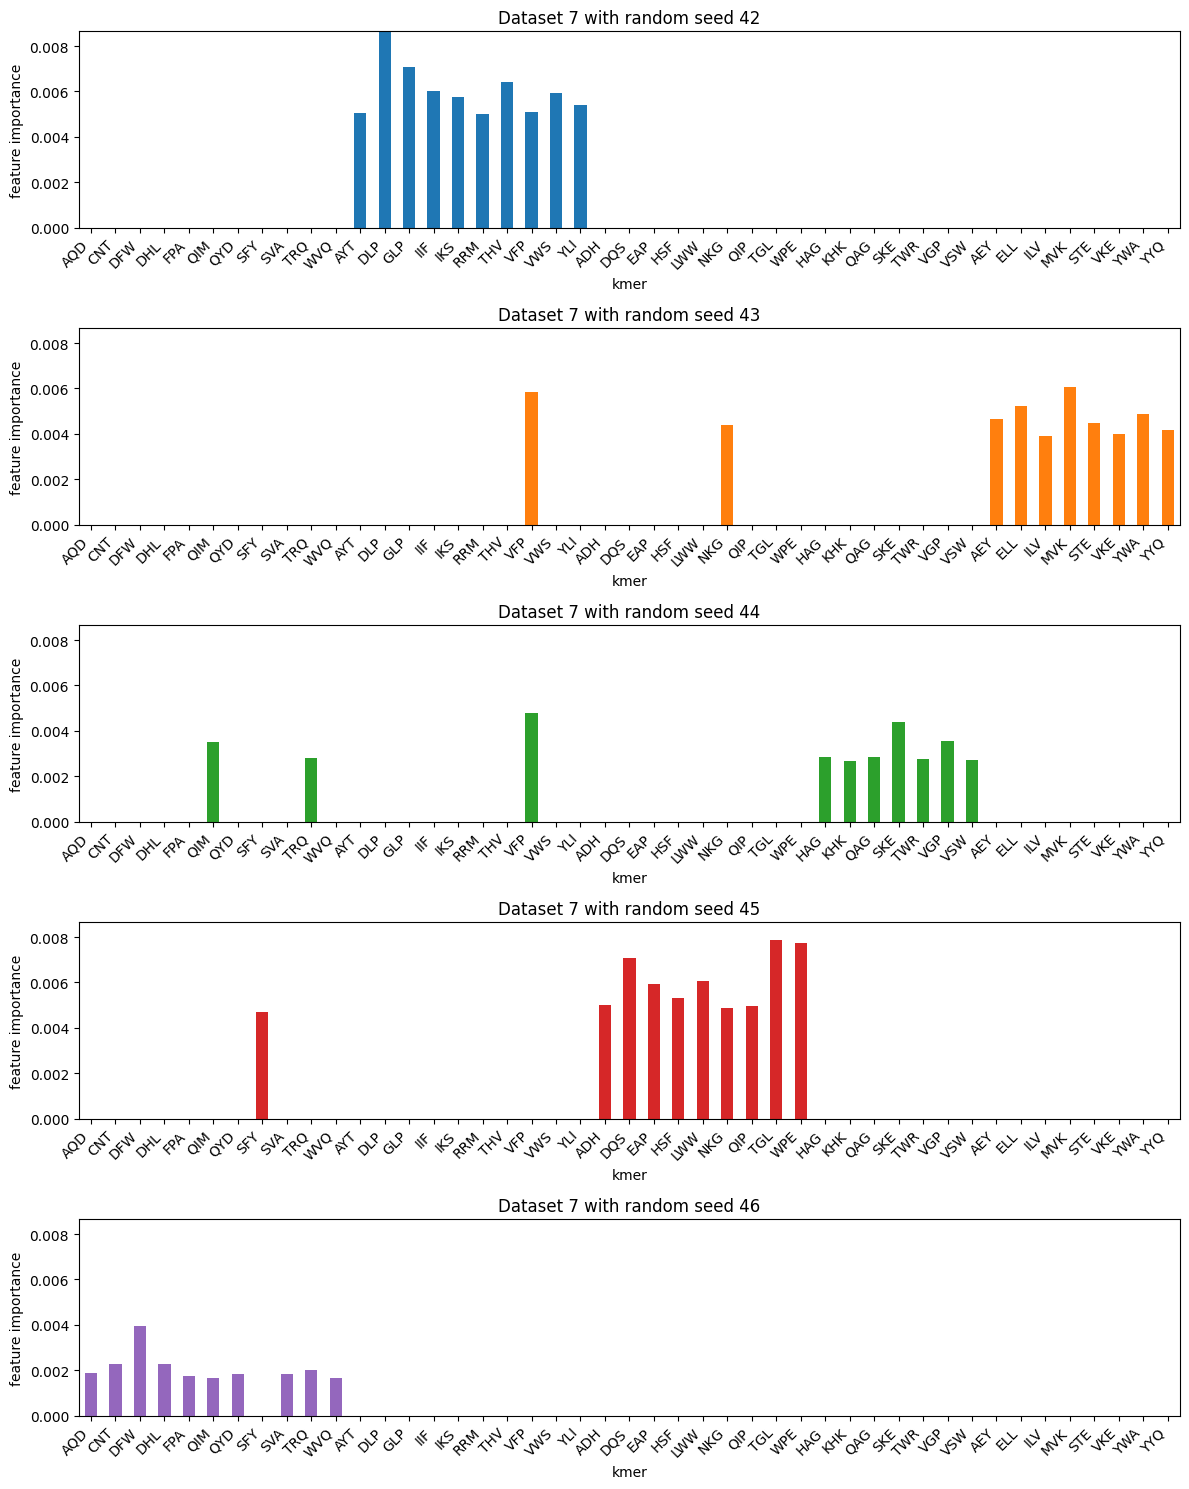

In [26]:
def filter_and_plot_importance(df, filter_col, filer_val, id_var, var_name, value_name, title, drop_cols=[]):
    df_filt = df[df[filter_col] == filer_val].copy()
    df_filt = df_filt.drop(columns=[filter_col]+drop_cols)
    df_filt = df_filt.dropna(axis=1, how='all')
    df_filt = df_filt.fillna(0)

    kmer_order = [col for col in df_filt.columns if col != id_var]
    
    df_long = df_filt.melt(id_vars=id_var, var_name=var_name, value_name=value_name)
    
    y_max = df_long[value_name].max()

    # Create FacetGrid
    groups = np.sort(df_long[id_var].unique())
    n_groups = len(groups)
    fig, axes = plt.subplots(n_groups, 1, figsize=(12, 3*n_groups), sharey=True)
    
    if n_groups == 1:
        axes = [axes]
    
    # Assign one color per seed
    colors = sns.color_palette("tab10", n_groups)
    palette_dict = dict(zip(groups, colors))
    
    for ax, group in zip(axes, groups):
        row = df_long[df_long[id_var]==group].set_index(var_name).loc[kmer_order]
        row[value_name].plot.bar(ax=ax, color=palette_dict[group])
        ax.set_title(f"{title} {group}")
        ax.set_ylim(0, y_max)
        
        # Show all k-mer labels under every plot
        ax.set_xticks(range(len(kmer_order)))
        ax.set_xticklabels(kmer_order, rotation=45, ha="right")
        ax.set_ylabel(value_name.replace('_', ' '))
    
    #plt.xlabel(var_name.replace('_', ' '))
    plt.tight_layout()
    plt.show()


filter_and_plot_importance(df_kaggle, filter_col = 'dataset', filer_val = 'dataset_7', id_var = 'random_seed', var_name = 'kmer', value_name = 'feature_importance', title='Dataset 7 with random seed')


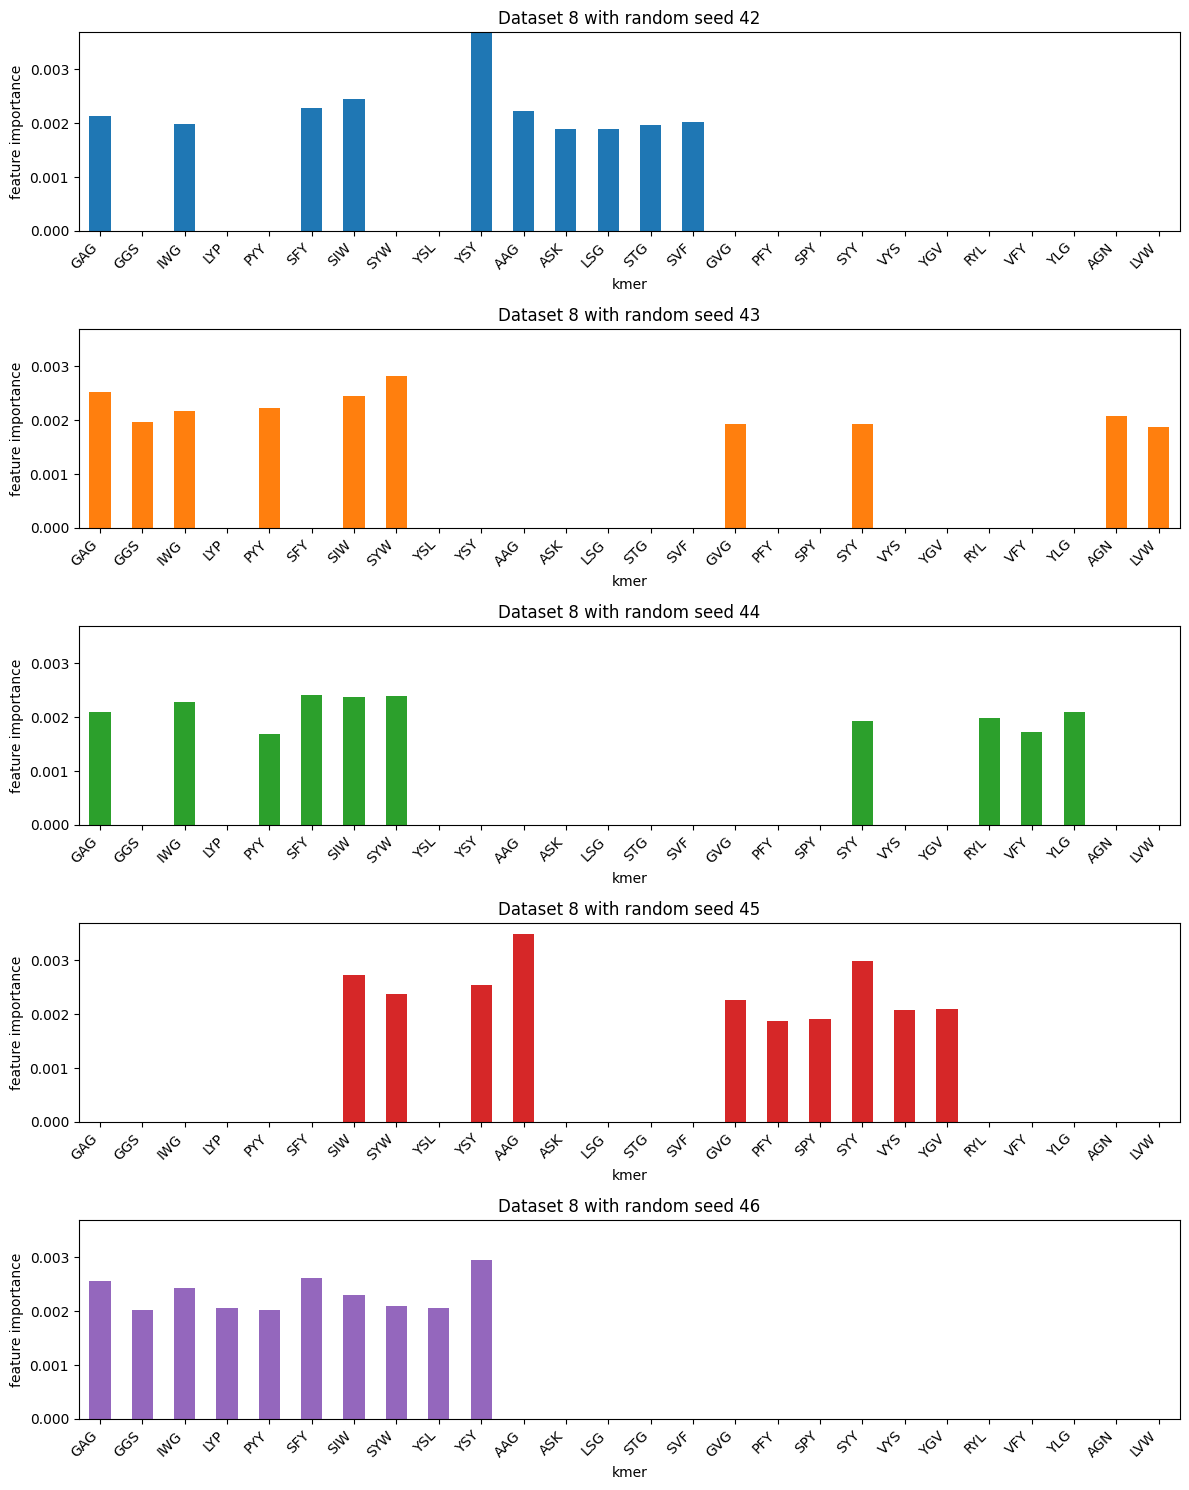

In [4]:
filter_and_plot_importance(df_kaggle, filter_col = 'dataset', filer_val = 'dataset_8', id_var = 'random_seed', var_name = 'kmer', value_name = 'feature_importance', title='Dataset 8 with random seed')


In [5]:
df_sim = pd.read_csv('./stats/sim_270/in_top10_features.csv', index_col='dataset_name')
df_sim

,AGP,ASS,EGP,GGP,GPK,KLF,KQY,LGP,NGP,PKA,...,SYE,ENT,RSS,GRN,RTS,SRP,seed,freq,size,noise
dataset_name,,,,,,,,,,,,,,,,,,,,,
simulated_seed3_freq010_size1000_noise5_dataset,NaN,NaN,0.031467,NaN,0.089478,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,10,1000,5
simulated_seed3_freq010_size1000_noise25_dataset,0.014078,NaN,0.016819,0.012309,0.106115,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,10,1000,25
simulated_seed3_freq010_size1000_noise50_dataset,0.006620,NaN,0.008468,0.007132,0.123355,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,10,1000,50
simulated_seed3_freq010_size1000_noise60_dataset,0.005144,NaN,0.006662,NaN,0.123301,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,10,1000,60
simulated_seed3_freq010_size1000_noise70_dataset,0.004874,NaN,0.003990,NaN,0.113701,NaN,NaN,0.003997,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3,10,1000,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
simulated_seed7_freq050_size150_noise25_dataset,0.022461,NaN,NaN,0.022133,0.029292,NaN,NaN,NaN,NaN,0.021256,...,NaN,NaN,NaN,NaN,NaN,NaN,7,50,150,25
simulated_seed7_freq050_size150_noise50_dataset,NaN,NaN,NaN,NaN,0.042985,NaN,NaN,NaN,NaN,0.028331,...,NaN,NaN,NaN,NaN,NaN,NaN,7,50,150,50
simulated_seed7_freq050_size150_noise60_dataset,NaN,NaN,NaN,0.017717,0.038868,NaN,NaN,NaN,NaN,0.032701,...,NaN,NaN,NaN,NaN,NaN,NaN,7,50,150,60


/tmp/ipykernel_2552644/1548710436.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2552644/1548710436.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2552644/1548710436.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2552644/1548710436.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2552644/1548710436.py:46: UserWarning

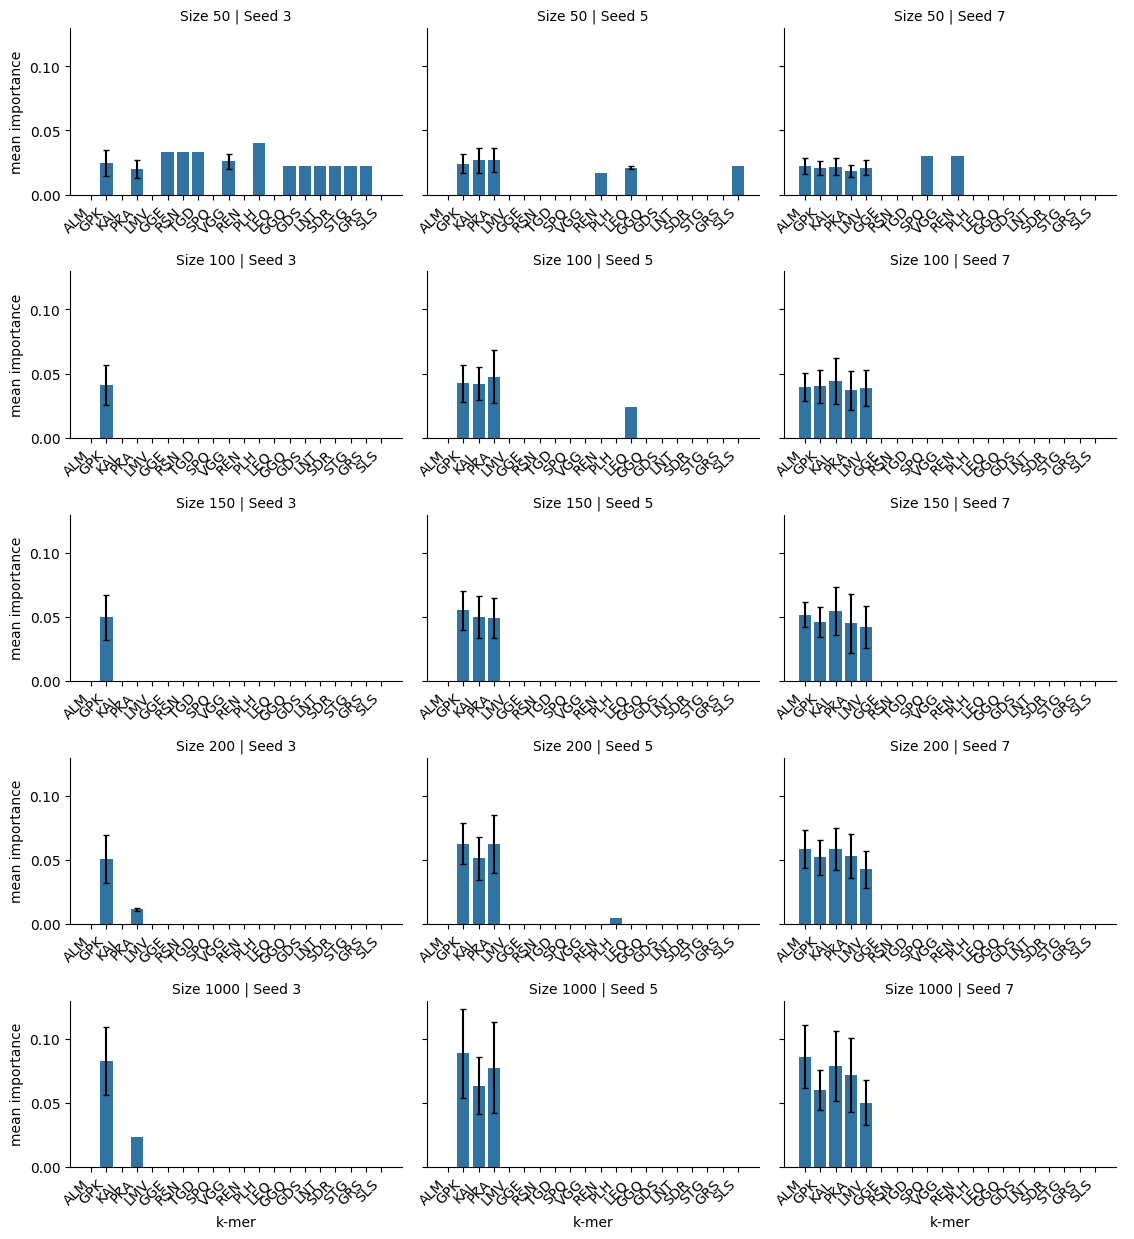

In [25]:
df_long = df_sim.melt(id_vars=['seed', 'freq', 'size', 'noise'])
df_plot = df_long.groupby(['seed', 'size', 'variable'])['value'].agg(['mean', 'std']).reset_index()

top_kmers = (
    df_plot.groupby("variable")["mean"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index
)

df_plot = df_plot[df_plot["variable"].isin(top_kmers)]

g = sns.catplot(
    data=df_plot,
    x="variable",
    y="mean",
    row="size",
    col="seed",
    kind="bar",
    order=top_kmers,
    sharey=True,
    height=2.5,
    aspect=1.5,
    errorbar=None
)

for ax, (size, seed) in zip(g.axes.flatten(), df_plot.groupby(["size", "seed"]).groups.keys()):
    
    subset = df_plot[(df_plot["size"] == size) & (df_plot["seed"] == seed)]
    
    subset = subset.set_index("variable").loc[top_kmers]  # enforce same order
    
    x = np.arange(len(top_kmers))
    
    ax.errorbar(
        x,
        subset["mean"],
        yerr=subset["std"],
        fmt="none",
        ecolor="black",
        capsize=2
    )

    ax.tick_params(axis="x", labelbottom=True)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

g.set_axis_labels("k-mer", "mean importance")
g.set_titles("Size {row_name} | Seed {col_name}")

plt.tight_layout()
plt.show()

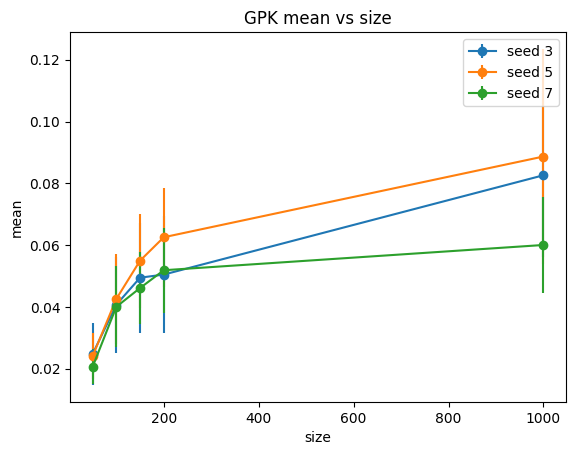

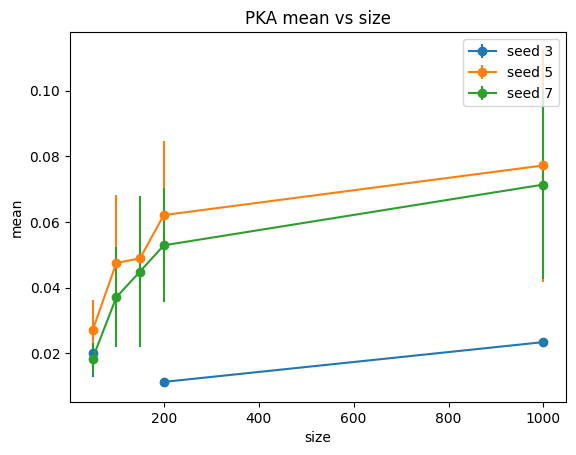

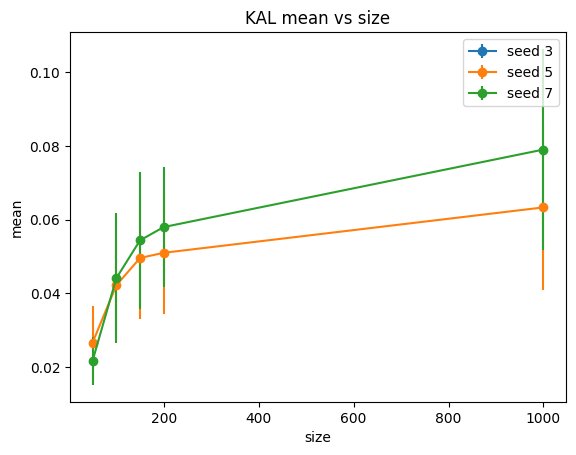

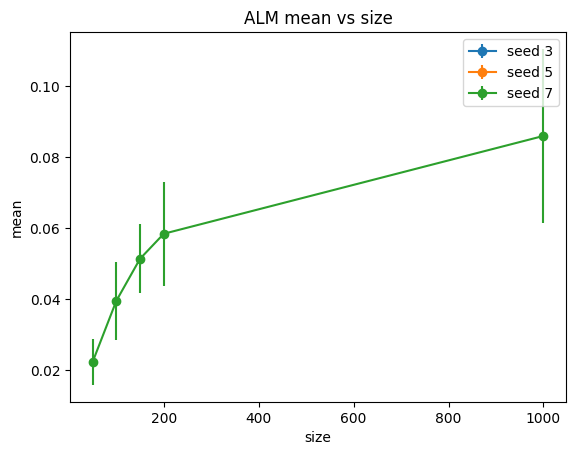

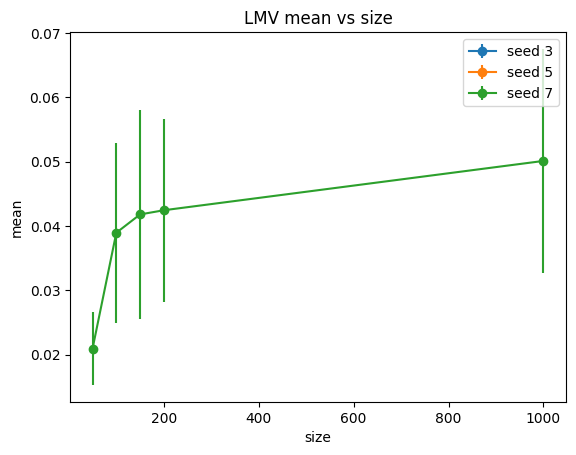

In [11]:
for kmer in ['GPK', 'PKA', 'KAL', 'ALM', 'LMV']:

    summary = df_sim.groupby(['size', 'seed']).agg(
        missing=(kmer, lambda x: x.isna().sum()),
        mean=(kmer, 'mean'),
        std=(kmer, 'std')
    ).reset_index()

    for seed, g in summary.groupby("seed"):
        g = g.sort_values("size")
        plt.errorbar(
            g["size"],
            g["mean"],
            yerr=g["std"],
            marker="o",
            label=f"seed {seed}"
        )

    plt.xlabel("size")
    plt.ylabel("mean")
    plt.title(f"{kmer} mean vs size")
    plt.legend()
    plt.show()